# 🧠 Model Interpretability using SHAP

---

# Objective

Building a highly accurate machine learning model is only part of the solution. Business stakeholders also need to understand why the model makes its predictions.

This notebook uses SHAP (SHapley Additive exPlanations) to explain the predictions made by the customer churn model.

The goals are to:

- Understand the most important features influencing churn.
- Explain individual customer predictions.
- Increase trust in the machine learning model.
- Convert model outputs into business insights.

# Why Explainability Matters

Traditional machine learning models often behave like black boxes.

For business applications, simply predicting customer churn is not enough.

Decision-makers need to know:

- Which factors increase churn?
- Which customers are most at risk?
- What actions can reduce churn?

SHAP assigns an importance value to every feature for every prediction, making complex models interpretable and transparent.

In [13]:
import pandas as pd
import numpy as np

import shap
import joblib

import matplotlib.pyplot as plt

In [14]:
model = joblib.load("customer_churn_model.pkl")

features = joblib.load("model_features.pkl")

C:\Users\Karan Singh\anaconda3\envs\customer_ai\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Karan Singh\anaconda3\envs\customer_ai\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [15]:
df = pd.read_csv("feature_dataset.csv")

In [16]:
X = df[features]

In [17]:
explainer = shap.TreeExplainer(model)

In [18]:
shap_values = explainer.shap_values(X)

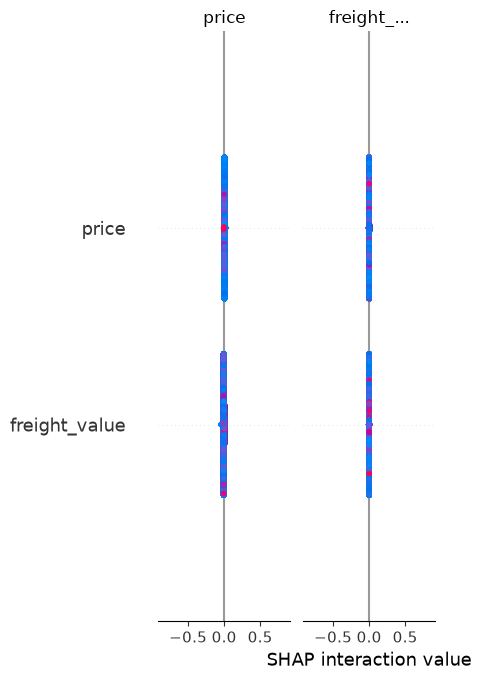

In [19]:
shap.summary_plot(
    shap_values,
    X
)

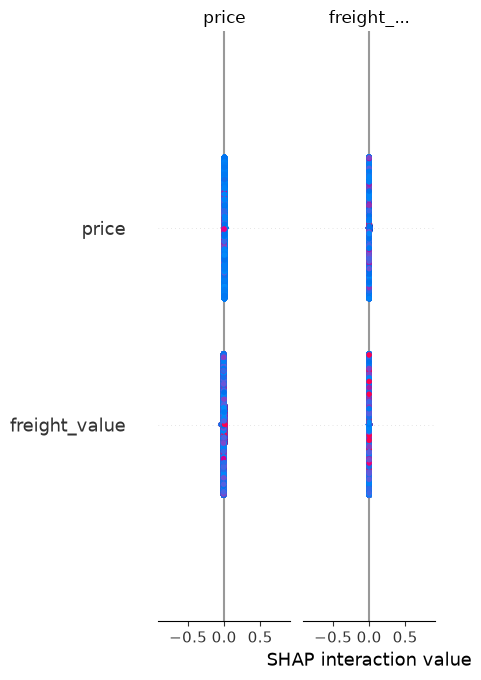

In [20]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

In [41]:
customer = 15

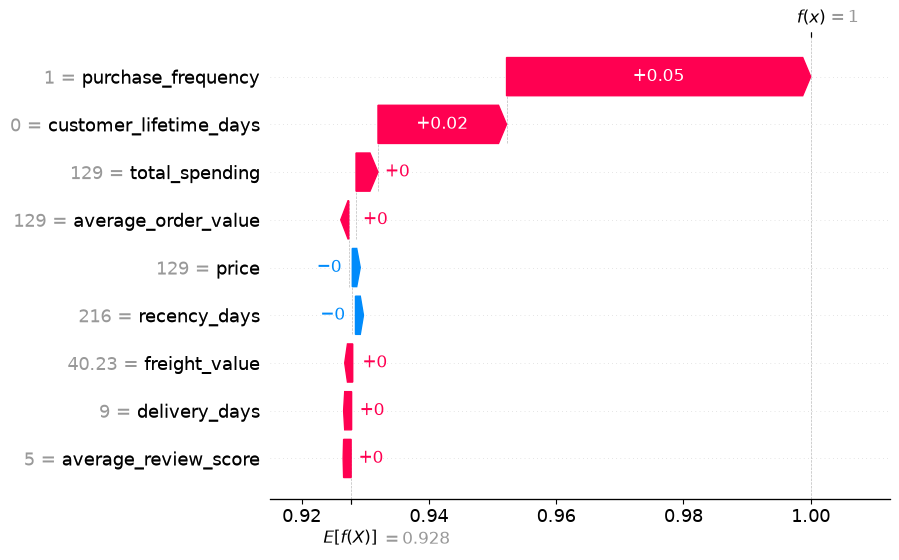

In [48]:
explanation = shap.Explanation(
    values=shap_values[customer][:, 1],          # Added [:, 1] to pick class 1
    base_values=explainer.expected_value[1],     # Added [1] to match class 1
    data=X.iloc[customer],
    feature_names=X.columns
)

shap.plots.waterfall(explanation)

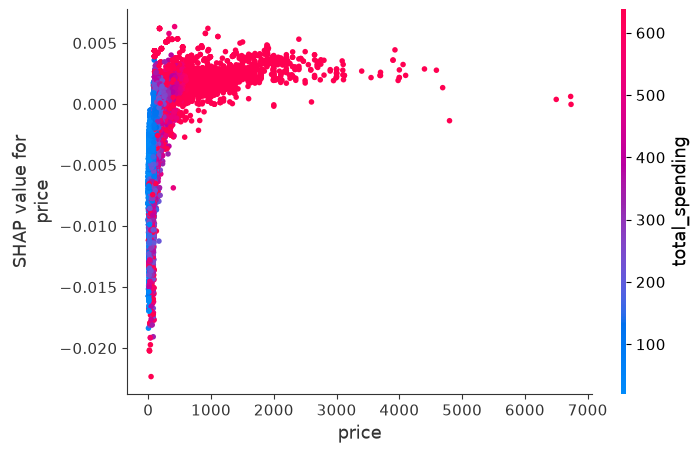

In [53]:
shap.dependence_plot(
    "price", 
    shap_values[..., 1],  # Added [..., 1] to select class 1
    X
)

<Figure size 1000x600 with 0 Axes>

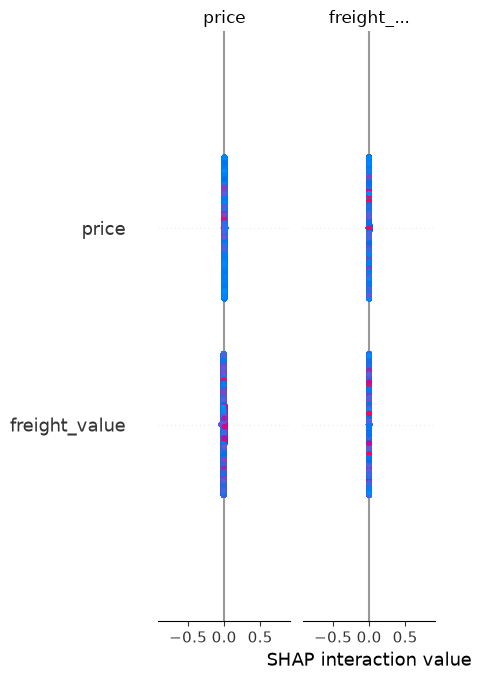

In [54]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X,
    show=False
)

plt.savefig("shap_summary.png", dpi=300)
plt.show()

## Business Insights

According to SHAP:

- Price has a strong impact on churn.
- Freight value influences customer satisfaction.
- Delivery delay increases churn probability.
- Customers with frequent purchases are less likely to churn.
- High-value customers should receive retention offers.

## Business Recommendations

Based on SHAP analysis, the following business actions are recommended:

• Improve logistics to reduce delivery delays.

• Offer loyalty rewards to high-frequency customers.

• Monitor customers with increasing freight costs.

• Reduce expensive product pricing through targeted promotions.

• Prioritize retention campaigns for customers showing high churn probability.

## Conclusion

In this notebook we interpreted the Random Forest model using SHAP.

Instead of treating the model as a black box, SHAP explained the contribution of every feature.

This enables business teams to understand why customers are predicted to churn and provides actionable insights for customer retention strategies.